In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

In [72]:
info = pd.read_csv('../data/tornadoes_all_humanimpact.csv')

In [73]:
info

,Unnamed: 0,YEAR,MONTH,RADAR_DIST,BEGIN_LAT,BEGIN_LON,TOR_F_SCALE,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,RADAR_COV
0,0,1990,6,91.212078,44.3700,-92.6300,1,0,0,0,0,25000.0,0.0,True
1,1,1990,5,25.755913,42.0800,-71.4000,0,0,0,0,0,2500.0,0.0,True
2,2,1990,6,86.672025,41.1000,-98.4700,0,0,0,0,0,2500.0,0.0,True
3,3,1990,6,115.815290,41.5200,-97.7300,0,0,0,0,0,25000.0,0.0,True
4,4,1990,6,127.396500,40.2500,-100.7500,4,0,0,0,0,2500000.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30246,30246,2025,9,164.471312,48.2490,-100.8390,-1,0,0,0,0,0.0,0.0,True
30247,30247,2025,6,55.949806,37.2391,-98.0398,0,0,0,0,0,0.0,0.0,True
30248,30248,2025,9,60.483547,47.1400,-100.1750,-1,0,0,0,0,0.0,0.0,True
30249,30249,2025,6,116.128617,36.1732,-101.1485,2,0,0,0,0,95000.0,0.0,True


Seems like even at 0-100 km away from the nearest radar, there is about 1-5 deaths or injuries per tornado event.

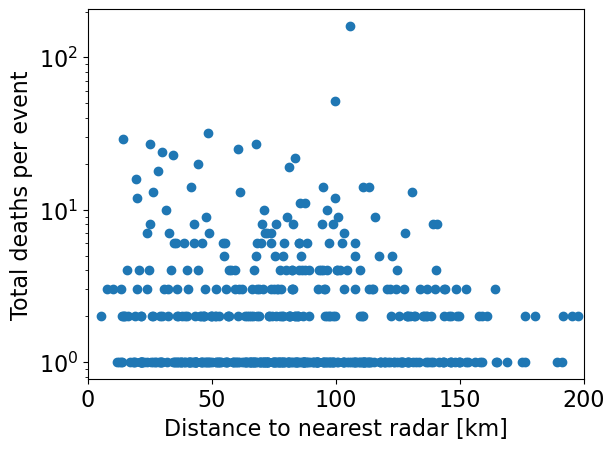

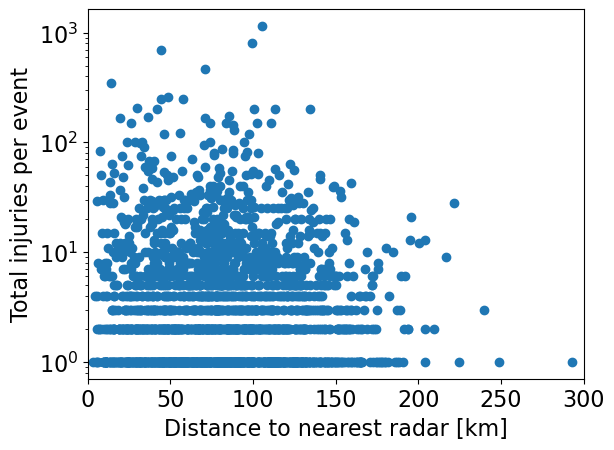

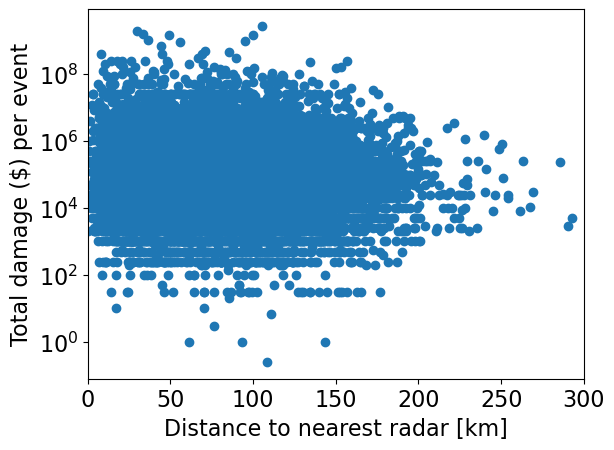

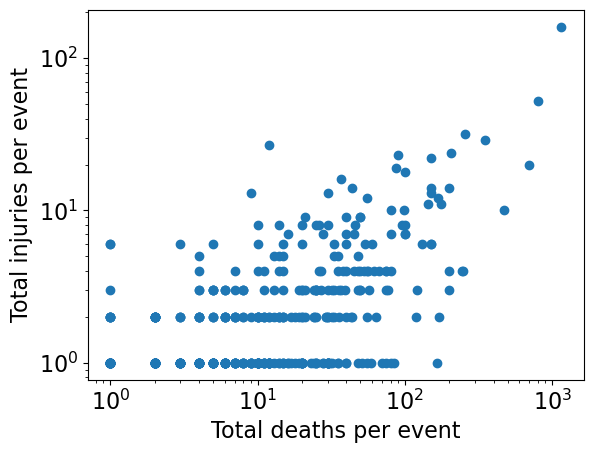

In [74]:
plt.figure()

total_deaths = np.array(info['DEATHS_DIRECT']) + np.array(info['DEATHS_INDIRECT'])

filt = total_deaths > 0

radar_dist = np.array(info['RADAR_DIST'])

plt.scatter(radar_dist[filt], total_deaths[filt])
plt.xlim([0,200])
plt.yscale('log')
plt.xlabel('Distance to nearest radar [km]')
plt.ylabel('Total deaths per event')
#plt.ylim([0,20])


plt.figure()
total_injuries = np.array(info['INJURIES_DIRECT']) + np.array(info['INJURIES_INDIRECT'])

filt = total_injuries > 0

radar_dist = np.array(info['RADAR_DIST'])

plt.scatter(radar_dist[filt], total_injuries[filt])
plt.xlim([0,300])
plt.yscale('log')
plt.xlabel('Distance to nearest radar [km]')
plt.ylabel('Total injuries per event')
#plt.ylim([0,20])


plt.figure()
total_damage = np.array(info['DAMAGE_PROPERTY']) + np.array(info['DAMAGE_CROPS'])

filt = total_damage > 0

radar_dist = np.array(info['RADAR_DIST'])

plt.scatter(radar_dist[filt], total_damage[filt])
plt.xlim([0,300])
plt.yscale('log')
plt.xlabel('Distance to nearest radar [km]')
plt.ylabel('Total damage ($) per event')



plt.figure()
total_deaths = np.array(info['DEATHS_DIRECT']) + np.array(info['DEATHS_INDIRECT'])
total_injuries = np.array(info['INJURIES_DIRECT']) + np.array(info['INJURIES_INDIRECT'])

filt = (total_deaths > 0) * (total_injuries > 0)
plt.scatter(total_injuries[filt], total_deaths[filt])
plt.xlabel('Total deaths per event')
plt.ylabel('Total injuries per event')
plt.xscale('log')
plt.yscale('log')
#plt.ylim([0,20])

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, GridSearchCV
import numpy as np

import matplotlib
plt.rcParams.update({'font.size': 12, 'text.usetex': False})
matplotlib.rc('font', family='serif')

In [79]:
df_filt = pd.read_csv('../data/tornadoes_all_humanimpact.csv', index_col=0)

In [80]:
features = pd.DataFrame({
    'BEGIN_LAT': np.array(df_filt['BEGIN_LAT']),
    'BEGIN_LON': np.array(df_filt['BEGIN_LON']),
    'MONTH' : np.array(df_filt['MONTH']),
    'RADAR_DIST': np.array(df_filt['RADAR_DIST'])
})

targets = pd.DataFrame({
    'DEATHS_TOTAL': np.array(df_filt['DEATHS_DIRECT']),
    'DEATHS_INDIRECT': np.array(df_filt['DEATHS_INDIRECT']),
    'INJURIES_DIRECT': np.array(df_filt['INJURIES_DIRECT']),
    'INJURIES_INDIRECT': np.array(df_filt['INJURIES_INDIRECT']),
    'DAMAGE_CROPS': np.array(df_filt['DAMAGE_CROPS']),
    'DAMAGE_PROPERTY': np.array(df_filt['DAMAGE_PROPERTY']),
})

<Axes: >

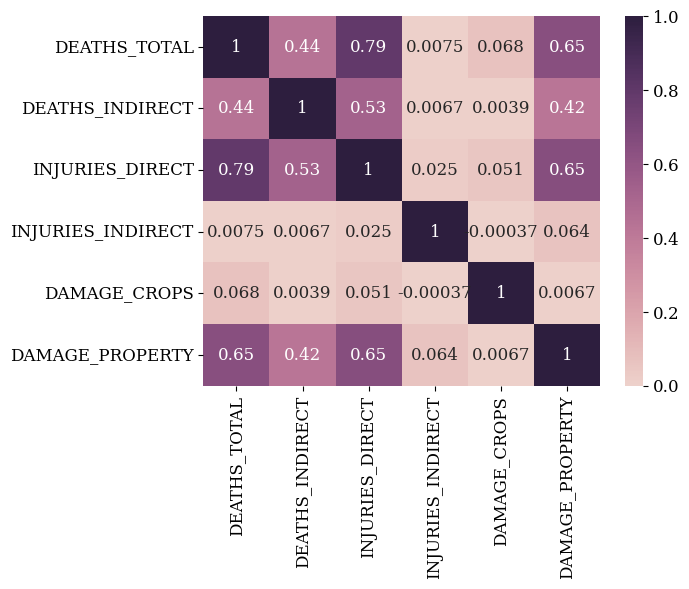

In [81]:
correlation = targets.corr()

plt.figure(facecolor='w')
sns.heatmap(correlation,cmap=sns.cubehelix_palette(as_cmap=True),annot=True)

In [82]:
#As a sanity check let's ensure all of these are the same size
print(len(features), len(targets))

# Scaling  -- do we need this?
# from sklearn import preprocessing
# scaler = preprocessing.StandardScaler().fit(features)
# scaled_spectra = scaler.transform(features)

from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor()
CV=KFold(shuffle = True, n_splits = 5, random_state=10) 
scores_models = cross_validate(forest_model, features, targets, cv = CV, return_train_score=True, scoring='r2') #

targets_pred = cross_val_predict(forest_model, features, targets, cv = CV)

scores = []
for i in range(5):
    scores.append(cross_validate(forest_model,features,
                                 targets[targets.columns[i]], 
                                 cv = KFold(n_splits=5, shuffle=True, random_state=10), 
                                 return_train_score=True, scoring = 'r2'))

30251 30251
